In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import feature_engineering_scaling as fes

In [7]:
from tensorflow.keras.models import load_model

# Load the saved model
model1_loaded = load_model("model_ann_214.h5")

In [8]:
# Predict the labels for the test set
y_pred1 = model1_loaded.predict(fes.X1_test)

# If using softmax, convert predictions to class labels
y_pred_classes1 = np.argmax(y_pred1, axis=1)

# Convert one-hot encoded true labels back to class labels
y_test_classes1 = np.argmax(fes.y1_test, axis=1)

54025/54025 [==============================] - 162s 3ms/step


In [9]:
# Define the binary mapping
binary_mapping = {
    0: 0,  # Map original class 0 to binary class 0
    1: 1,  # Map original class 1 to binary class 1
    2: 1,  # Map original class 2 to binary class 1
    3: 0,  # Map original class 3 to binary class 0
}


In [29]:
# Use y_pred1 (probabilities) instead of y_pred_classes1
binary_probs = np.zeros(len(y_pred1))
for original_class, binary_class in binary_mapping.items():
    binary_probs += y_pred1[:, original_class] * (binary_class == 1)


In [30]:
# Convert true labels to binary labels
binary_truth = np.array([binary_mapping[x] for x in fes.y1_test.argmax(axis=1)])


In [31]:
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(binary_truth, binary_probs)
roc_auc = auc(fpr, tpr)

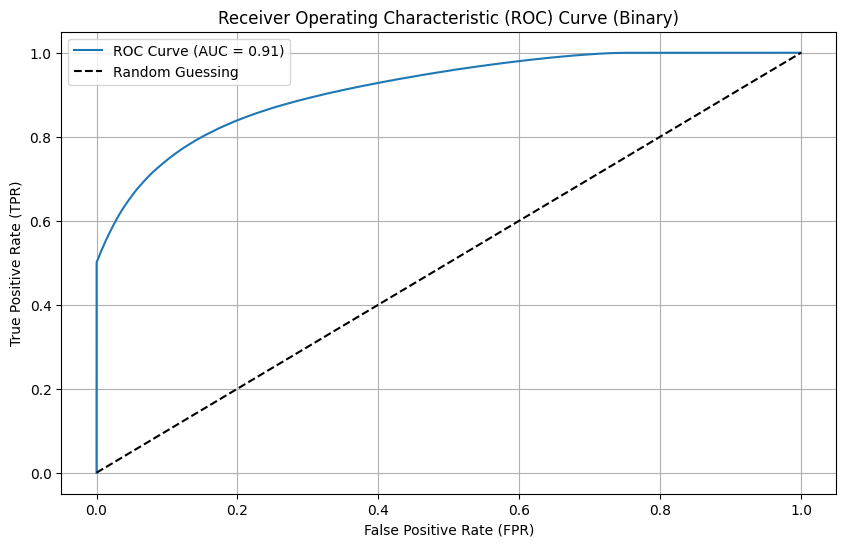

In [32]:
# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve (Binary)')
plt.legend()
plt.grid()
plt.show()

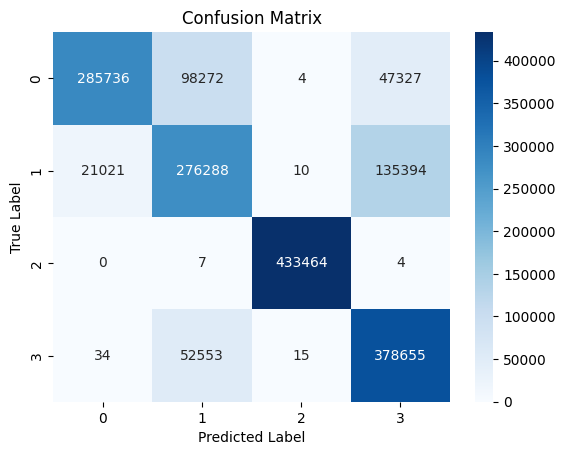

In [16]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
# Plot confusion matrix
conf_matrix1 = confusion_matrix(y_test_classes1, y_pred_classes1)
sns.heatmap(conf_matrix1, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Calculate metrics
precision_macro = precision_score(y_test_classes1, y_pred_classes1, average='macro')
recall_macro = recall_score(y_test_classes1, y_pred_classes1, average='macro')
f1_macro = f1_score(y_test_classes1, y_pred_classes1, average='macro')

precision_micro = precision_score(y_test_classes1, y_pred_classes1, average='micro')
recall_micro = recall_score(y_test_classes1, y_pred_classes1, average='micro')
f1_micro = f1_score(y_test_classes1, y_pred_classes1, average='micro')

precision_weighted = precision_score(y_test_classes1, y_pred_classes1, average='weighted')
recall_weighted = recall_score(y_test_classes1, y_pred_classes1, average='weighted')
f1_weighted = f1_score(y_test_classes1, y_pred_classes1, average='weighted')

# Create a summary table for F1, Recall, and Precision
metrics_summary = pd.DataFrame({
    'Metric': [
        'Precision (Macro)', 'Recall (Macro)', 'F1 Score (Macro)',
        'Precision (Micro)', 'Recall (Micro)', 'F1 Score (Micro)',
        'Precision (Weighted)', 'Recall (Weighted)', 'F1 Score (Weighted)'
    ],
    'Score': [
        precision_macro, recall_macro, f1_macro,
        precision_micro, recall_micro, f1_micro,
        precision_weighted, recall_weighted, f1_weighted
    ]
})

# Display the table
print(metrics_summary)

                 Metric     Score
0     Precision (Macro)  0.813168
1        Recall (Macro)  0.794736
2      F1 Score (Macro)  0.794938
3     Precision (Micro)  0.794861
4        Recall (Micro)  0.794861
5      F1 Score (Micro)  0.794861
6  Precision (Weighted)  0.813274
7     Recall (Weighted)  0.794861
8   F1 Score (Weighted)  0.795072


In [18]:
# Load the saved model
model2_loaded = load_model("model_ann_212.h5")

In [19]:
# Predict the labels for the test set
y_pred2 = model2_loaded.predict(fes.X2_test)

# If using softmax, convert predictions to class labels
y_pred_classes2 = np.argmax(y_pred2, axis=1)

# Convert one-hot encoded true labels back to class labels
y_test_classes2 = np.argmax(fes.y2_test, axis=1)

53464/53464 [==============================] - 194s 4ms/step


In [20]:
# Define the binary mapping
binary_mapping_2 = {
    0: 0,  # Map original class 0 to binary class 0
    3: 0,  # Map original class 3 to binary class 0
    4: 1,  # Map original class 4 to binary class 1
    5: 1,  # Map original class 5 to binary class 1
}


In [21]:
# Use y_pred1 (probabilities) instead of y_pred_classes1
binary_probs_2 = np.zeros(len(y_pred2))
for original_class, binary_class in binary_mapping_2.items():
    binary_probs_2 += y_pred2[:, original_class] * (binary_class == 1)

In [22]:
# Convert true labels to binary labels
binary_truth_2 = np.array([binary_mapping_2[x] for x in fes.y2_test.argmax(axis=1)])

In [23]:
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(binary_truth_2, binary_probs_2)
roc_auc = auc(fpr, tpr)

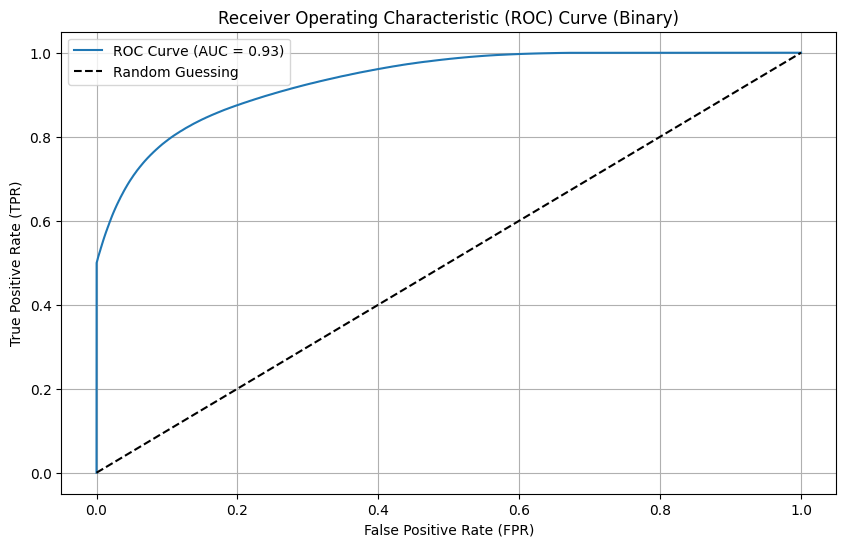

In [24]:
# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve (Binary)')
plt.legend()
plt.grid()
plt.show()

In [25]:
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print("Optimal Threshold:", optimal_threshold)


Optimal Threshold: 0.4895089870494048


In [26]:
# Apply the optimal threshold to the predicted probabilities to make binary predictions
y_pred_custom = (binary_truth_2 >= optimal_threshold).astype(int)

In [27]:
# Optionally: Evaluate the performance with the custom threshold
from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy with optimal threshold:", accuracy_score(y_test_classes2, y_pred_custom))
print("Confusion Matrix with optimal threshold:")
print(confusion_matrix(y_test_classes2, y_pred_custom))

Accuracy with optimal threshold: 0.2525505164160086
Confusion Matrix with optimal threshold:
[[432071      0      0      0      0]
 [     0      0      0      0      0]
 [431059      0      0      0      0]
 [     0 424809      0      0      0]
 [     0 422891      0      0      0]]


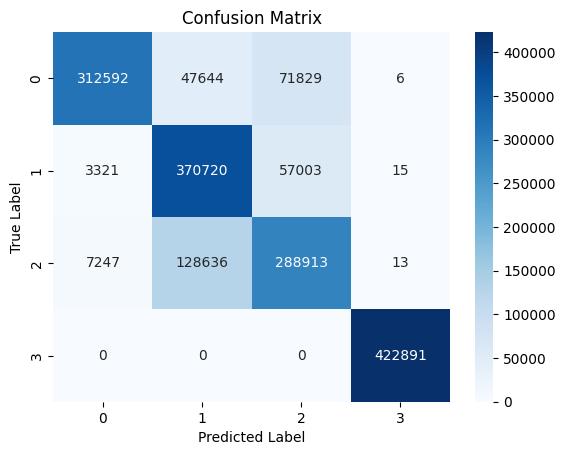

In [20]:
# Plot confusion matrix
conf_matrix2 = confusion_matrix(y_test_classes2, y_pred_classes2)
sns.heatmap(conf_matrix2, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [21]:
# Calculate metrics
precision_macro = precision_score(y_test_classes2, y_pred_classes2, average='macro')
recall_macro = recall_score(y_test_classes2, y_pred_classes2, average='macro')
f1_macro = f1_score(y_test_classes2, y_pred_classes2, average='macro')

precision_micro = precision_score(y_test_classes2, y_pred_classes2, average='micro')
recall_micro = recall_score(y_test_classes2, y_pred_classes2, average='micro')
f1_micro = f1_score(y_test_classes2, y_pred_classes2, average='micro')

precision_weighted = precision_score(y_test_classes2, y_pred_classes2, average='weighted')
recall_weighted = recall_score(y_test_classes2, y_pred_classes2, average='weighted')
f1_weighted = f1_score(y_test_classes2, y_pred_classes2, average='weighted')

# Create a summary table for F1, Recall, and Precision
metrics_summary = pd.DataFrame({
    'Metric': [
        'Precision (Macro)', 'Recall (Macro)', 'F1 Score (Macro)',
        'Precision (Micro)', 'Recall (Micro)', 'F1 Score (Micro)',
        'Precision (Weighted)', 'Recall (Weighted)', 'F1 Score (Weighted)'
    ],
    'Score': [
        precision_macro, recall_macro, f1_macro,
        precision_micro, recall_micro, f1_micro,
        precision_weighted, recall_weighted, f1_weighted
    ]
})

# Display the table
print(metrics_summary)

                 Metric     Score
0     Precision (Macro)  0.834138
1        Recall (Macro)  0.815899
2      F1 Score (Macro)  0.817910
3     Precision (Micro)  0.815462
4        Recall (Micro)  0.815462
5      F1 Score (Micro)  0.815462
6  Precision (Weighted)  0.833946
7     Recall (Weighted)  0.815462
8   F1 Score (Weighted)  0.817529
